# 데이터 전처리 과정

[Notion | https://www.notion.so/ryudoyeon/28b61f7ccc3f801ba078cf6d53c176ac?source=copy_link]

Data Curation과정: data/load_data.py 참고 

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

광명금속

In [43]:
data = pd.read_csv("data/processed/광명금속_시계열_데이터(2024.08_2025.09).csv")
data

,datetime,사용량 (kWh),최대수요 (kW),무효전력 (kVarh)_지상,무효전력 (kVarh)_진상,CO2 (tCO2),역률 (%)_지상,역률 (%)_진상
0,2024-08-06 00:15:00,1.16,4.64,0.50,0.0,0.0,91.83,100.0
1,2024-08-06 00:30:00,1.50,6.00,0.40,0.0,0.0,96.62,100.0
2,2024-08-06 00:45:00,1.06,4.24,0.44,0.0,0.0,92.36,100.0
3,2024-08-06 01:00:00,1.04,4.16,0.34,0.0,0.0,95.05,100.0
4,2024-08-06 01:15:00,1.00,4.00,0.18,0.0,0.0,98.42,100.0
...,...,...,...,...,...,...,...,...
40411,2025-09-30 23:00:00,4.14,16.56,0.12,0.0,0.0,99.96,100.0
40412,2025-09-30 23:15:00,3.82,15.28,0.00,0.0,0.0,100.00,100.0
40413,2025-09-30 23:30:00,3.82,15.28,0.00,0.0,0.0,100.00,100.0
40414,2025-09-30 23:45:00,3.84,15.36,0.00,0.0,0.0,100.00,100.0


## Data Inspection

컬럼명 확인
- datetime
- 사용량 (kWh)
- 최대수요 (kW)
- 무효전력 (kVarh)_지상
- 무효전력 (kVarh)_진상
- CO2 (tCO2)
- 역률 (%)_지상
- 역률 (%)_진상

In [44]:
# 컬럼명 확인
data.columns
# 컬럼 영어로 변경
data.columns = ['datetime', 'usage_kWh', 'max_demand_kW', 'reactive_power_kVarh_inductive', 'reactive_power_kVarh_capacitive', 'CO2_tCO2', 'power_factor_inductive', 'power_factor_capacitive']

이상치, 결측치 확인
- 결측치 없음

In [45]:
nans= data.isna().sum()
print(nans)

datetime                           0
usage_kWh                          0
max_demand_kW                      0
reactive_power_kVarh_inductive     0
reactive_power_kVarh_capacitive    0
CO2_tCO2                           0
power_factor_inductive             0
power_factor_capacitive            0
dtype: int64


변수별 시각화

In [46]:
feature_cols = [col for col in data.columns if col != 'datetime' and col != 'usage_kWh']

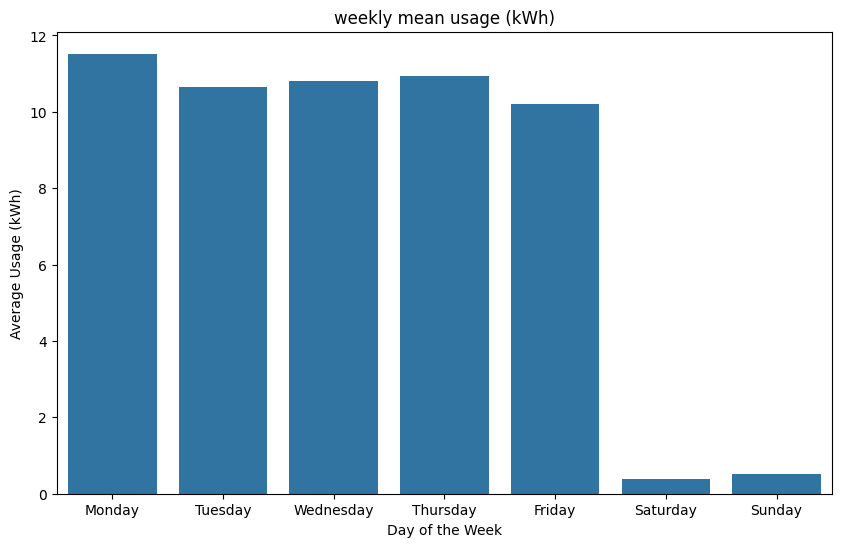

In [47]:
# 요일별 평균 사용량 시각화

# 날짜별 요일 추출
data['datetime'] = pd.to_datetime(data['datetime'])
data['day_of_week'] = data['datetime'].dt.day_name()

# 요일별 평균 사용량 계산
avg_usage_by_day = data.groupby('day_of_week')['usage_kWh'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_usage_by_day.index, y=avg_usage_by_day.values)
plt.title('weekly mean usage (kWh)')
plt.xlabel('Day of the Week')
plt.ylabel('Average Usage (kWh)')
plt.show()
# day_of_week 열 삭제
data.drop(columns=['day_of_week'], inplace=True)

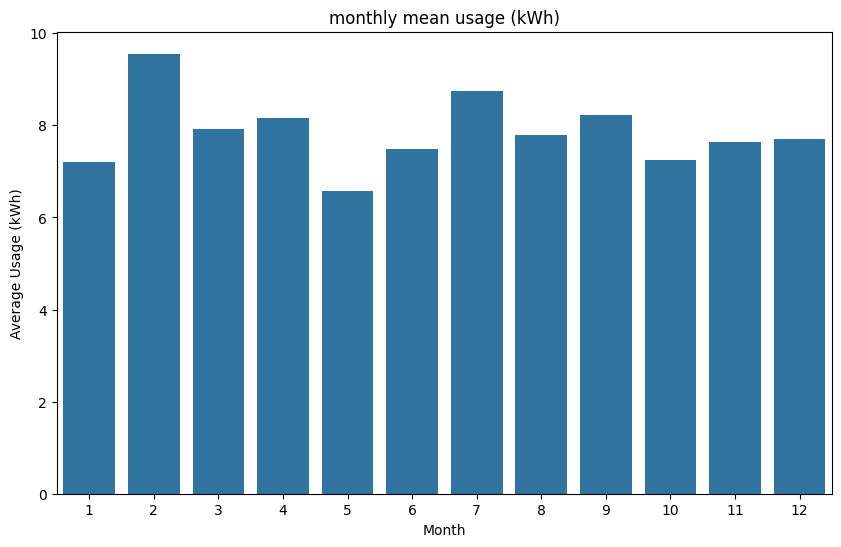

In [48]:
# 월별 평균 사용량 시각화

# 날짜별 월 추출
data['month'] = data['datetime'].dt.month
# 월별 평균 사용량 계산
avg_usage_by_month = data.groupby('month')['usage_kWh'].mean()
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_usage_by_month.index, y=avg_usage_by_month.values)
plt.title('monthly mean usage (kWh)')
plt.xlabel('Month')
plt.ylabel('Average Usage (kWh)')
plt.show()
# month 열 삭제
data.drop(columns=['month'], inplace=True)

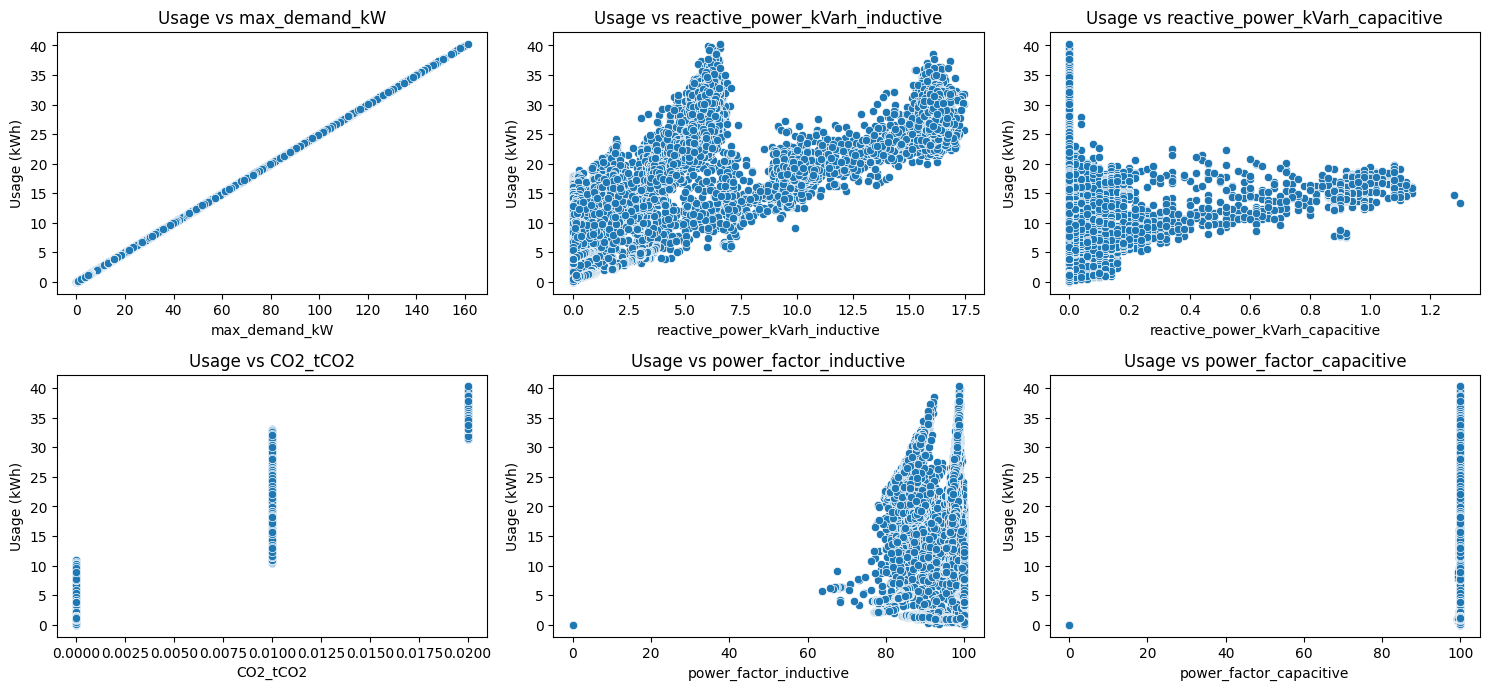

In [49]:
# 각 변수별 사용량과의 상관관계 산점도

plt.figure(figsize=(15, 10))
for i, col in enumerate(feature_cols):
    plt.subplot(3, 3, i + 1)
    sns.scatterplot(data=data, x=col, y='usage_kWh')
    plt.title(f'Usage vs {col}')
    plt.xlabel(col)
    plt.ylabel('Usage (kWh)')
plt.tight_layout()
plt.show()

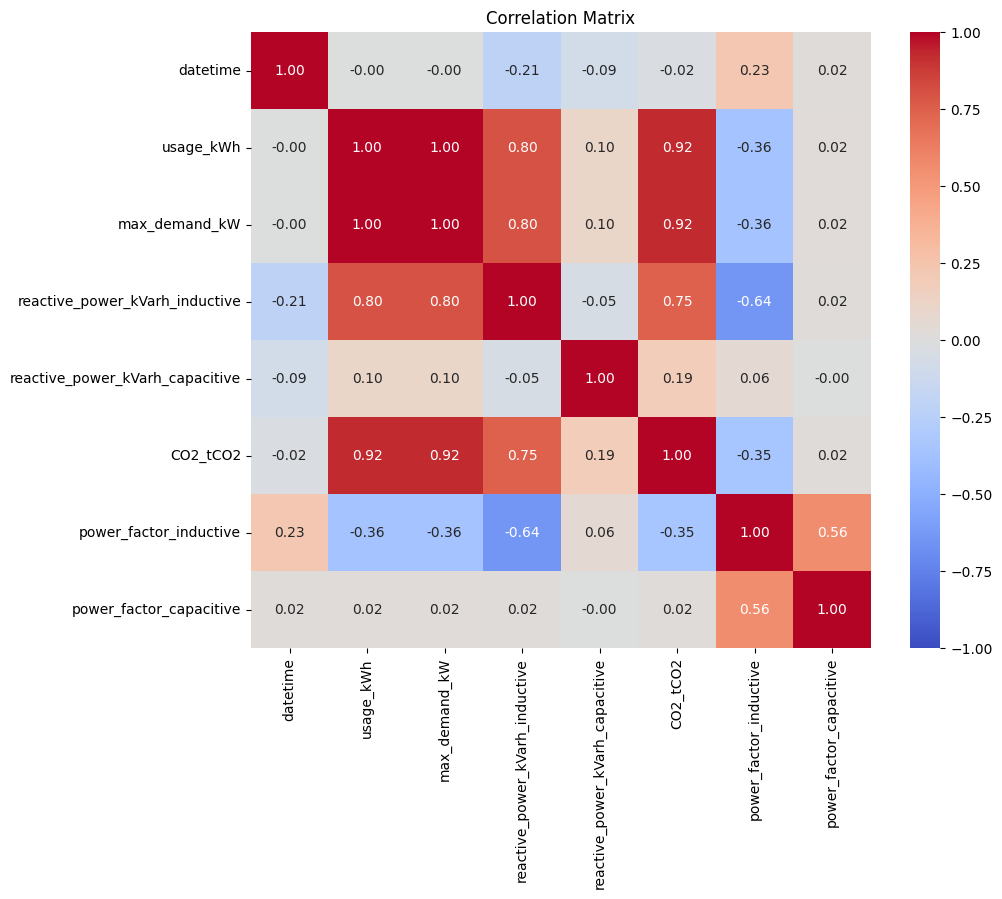

In [50]:
# 각 변수별 사용량과의 상관관계 히트맵

plt.figure(figsize=(10, 8))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

## Data Preprocessing

In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40416 entries, 0 to 40415
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   datetime                         40416 non-null  datetime64[ns]
 1   usage_kWh                        40416 non-null  float64       
 2   max_demand_kW                    40416 non-null  float64       
 3   reactive_power_kVarh_inductive   40416 non-null  float64       
 4   reactive_power_kVarh_capacitive  40416 non-null  float64       
 5   CO2_tCO2                         40416 non-null  float64       
 6   power_factor_inductive           40416 non-null  float64       
 7   power_factor_capacitive          40416 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 2.5 MB


Train / Valid / Test 분리하기
- train: 80%
- valid: 15
- test: 15%

In [52]:
def split_train_val_test(data=data, train_ratio=0.7, val_ratio=0.15):    
    train_data = pd.DataFrame()
    val_data = pd.DataFrame()
    test_data = pd.DataFrame()

    total_len = len(data)
    train_end = int(total_len * train_ratio)
    val_end = int(total_len * (train_ratio + val_ratio))

    train_data = pd.concat([train_data, data.iloc[:train_end]])
    val_data = pd.concat([val_data, data.iloc[train_end:val_end]])
    test_data = pd.concat([test_data, data.iloc[val_end:]])

    # 인덱스 재설정
    train_data = train_data.reset_index(drop=True)
    val_data = val_data.reset_index(drop=True)
    test_data = test_data.reset_index(drop=True)

    return train_data, val_data, test_data

In [54]:
train, valid, test = split_train_val_test(data)

train_y = pd.DataFrame(train['usage_kWh'])
valid_y = pd.DataFrame(valid['usage_kWh'])
test_y = pd.DataFrame(test['usage_kWh'])

In [56]:
# 분할된 시계열 데이터 범위 확인
def get_date_range(df):
    date_ranges = {}
    min_date = pd.to_datetime(df['datetime']).min()
    max_date = pd.to_datetime(df['datetime']).max()
    date_ranges = {min_date, max_date}
    return date_ranges

print("Train Date:\n", get_date_range(train))
print("Validation Date:\n", get_date_range(valid))
print("Test Date:\n", get_date_range(test))

Train Date:
 {Timestamp('2025-05-27 16:45:00'), Timestamp('2024-08-06 00:15:00')}
Validation Date:
 {Timestamp('2025-07-29 20:15:00'), Timestamp('2025-05-27 17:00:00')}
Test Date:
 {Timestamp('2025-07-29 20:30:00'), Timestamp('2025-10-01 00:00:00')}


In [58]:
# datetime 컬럼 제거
train = train.drop(columns=["datetime"])
valid = valid.drop(columns=["datetime"])
test = test.drop(columns=["datetime"])

Data cleaning

In [59]:
# 이상치 NaN값 처리 

# NaN값 처리 

# NaN값은 현재 없는 상태라 생략

정규화, 표준화

In [60]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

MinMaxscaler = MinMaxScaler() # 0~1 사이로 정규화
Standardscaler = StandardScaler() # 평균 0, 표준편차 1로 표준화

# train_data
# fit_transform 모두 
def train_scaler_fit_transform(df, scaler):
    df = df.copy()
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    return df, scaler

# valid / test_data
# transform only
def valid_test_scaler_transform(df, scaler):
    df = df.copy()
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[numeric_cols] = scaler.transform(df[numeric_cols])
    return df

# Min-Max scaling
train_minmax, minmax_scaler = train_scaler_fit_transform(train, MinMaxscaler)
valid_minmax = valid_test_scaler_transform(valid, minmax_scaler)
test_minmax = valid_test_scaler_transform(test,  minmax_scaler)

# z-score standardization
train_scaled, standard_scaler = train_scaler_fit_transform(train_minmax, Standardscaler)
valid_scaled = valid_test_scaler_transform(valid_minmax, standard_scaler)
test_scaled  = valid_test_scaler_transform(test_minmax, standard_scaler)

In [61]:
# target power에 대해서도 동일하게 진행
# feature / target 분리해서 진행해야 함
# y_xx_scaled: 추후 역변환 시 사용

# Min-Max scaling
train_minmax_y, y_minmax_scaled = train_scaler_fit_transform(train_y, MinMaxscaler)
valid_minmax_y = valid_test_scaler_transform(valid_y, MinMaxscaler)
test_minmax_y = valid_test_scaler_transform(test_y, MinMaxscaler)

# z-score standardization
train_scaled_y, y_standard_scaled = train_scaler_fit_transform(train_minmax_y, Standardscaler)
valid_scaled_y = valid_test_scaler_transform(valid_minmax_y, Standardscaler)
test_scaled_y  = valid_test_scaler_transform(test_minmax_y, Standardscaler)

슬라이딩 윈도우 생성

In [63]:
import torch
def sliding_window(df, input_window, output_window,
                    target_col="power", keep_target_in_x=True):
    """
    Function: sliding_window
        - input_window 길이 만큼의 슬라이딩 윈도우를 사용하여
          output_window 길이 만큼의 타겟 생성
    Parameters:
        - df: pandas DataFrame, 단일 발전소의 시계열 데이터 (tgt_station(mono_station / poly_station))
        - input_window: input_window 길이 
        - output_window: output_window 길이
        - target_col: 타겟 컬럼명 (default: "power")
        - keep_target_in_x: 입력 피처에 타겟 컬럼 포함 여부 (default: True)
    Returns:
        - x_arr: torch.Tensor, shape (N, input_window, F)
        - y_arr: torch.Tensor, shape (N, output_window) or (N,)
          (output_window=1일 때는 (N,)로 차원 축소)
        - N: 생성된 샘플 수
    Note:
        - N = T - input_window - output_window + 1 (T: 전체 타임스탬프 수)
        - F: feature 수
        - L: input_window
    """
    xs, ys = [], [] # 입력과 타겟 리스트

    # 인덱스 초기화
    sub = df.reset_index(drop=True)

    # 숫자형 feature 선택
    numeric_cols = sub.select_dtypes(include=[np.number]).columns.tolist()
    feat_cols = numeric_cols.copy()
    if not keep_target_in_x:
        feat_cols = [c for c in feat_cols if c != target_col]
    
    X = sub[feat_cols].to_numpy()
    y_all = pd.to_numeric(sub[target_col], errors="coerce").to_numpy()

    T = len(sub)
    N = T - input_window - output_window + 1
    if N <= 0:
        return None, None

    for i in range(N):
        xs.append(X[i:i+input_window]) #
        ys.append(y_all[i+input_window:i+input_window+output_window])

    x_arr = np.stack(xs).astype(np.float32) # (N, L, F)
    y_arr = np.stack(ys).astype(np.float32) # (N, output_window)

    # output_window = 1 일 때 차원 축소 (N, 1) -> (N,)
    if y_arr.shape[1] == 1:
        y_arr = y_arr[:, 0]

    return torch.from_numpy(x_arr), torch.from_numpy(y_arr) # torch.Tensor로 변환

In [66]:
input_window = 10 #  15 * 10 분 입력
output_window = 1 # 15분 예측

# sliding_window, torch.Tensor 변환
torch_train_x, torch_train_y = sliding_window(
    train_scaled, input_window, output_window,
    target_col="usage_kWh", keep_target_in_x=True
)

In [67]:
torch_valid_x, torch_valid_y = sliding_window(
    valid_scaled, input_window, output_window,
    target_col="usage_kWh", keep_target_in_x=True
)

In [68]:
torch_test_x, torch_test_y = sliding_window(
    test_scaled, input_window, output_window,
    target_col="usage_kWh", keep_target_in_x=True
)

# Model initilization and train

In [91]:
# CNN 파라미터 설정

in_channels = train_scaled.shape[1] # 입력 피처 수 (station의 기상 변수 + power)
out_channels = 64 # CNN에서 추출할 feature map 수 (입력 feature를 통해 out_channels 수 만큼 새로운 특징 추출)
kernel_size = 3 # 커널 크기
stride = 1 # kernel 이동 간격
dilation = 1 # kernel 사이의 간격
padding = 1 # 입력 양 쪽에 채워 넣는 padding 크기
groups = 1 # 1: default
bias = True # bias 사용
padding_mode = 'zeros' # padding 채우는 값
cnn_dropout = 0.1 # dropout 비율
pool_kernel_size = 2 # MaxPooling kernel size
pool_stride = 2 # MaxPooling stride
dropout=0.1
next_in_features = 32 # LSTM 입력 피처 수 # out_channels에서 fully connected layer로 축소
use_bn = True # Batch Normalization 사용 여부

In [92]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from models.CNN import CNN
# CNN 모델 생성
cnn = CNN(
    in_channels=in_channels,
    out_channels=out_channels,
    kernel_size=kernel_size,
    stride=stride,
    dilation=dilation,
    padding=padding,
    groups=groups,
    bias=bias,
    padding_mode=padding_mode,
    dropout=cnn_dropout,
    pool_kernel_size=pool_kernel_size,
    pool_stride=pool_stride,
    next_in_features=next_in_features,
    use_bn=use_bn
).to(device)
cnn

CNN(
  (cnn): Conv1d(7, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.1, inplace=False)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): LazyLinear(in_features=0, out_features=32, bias=True)
)

In [93]:
from models.LSTM import LSTM
# LSTM 모델 생성
# LSTM 파라미터 설정
input_size = next_in_features # LSTM 입력 피처 수 # CNN 모델의 출력 피처 수와 동일
hidden_size = 100 # LSTM hidden state 크기
output_size = output_window # 예측하고자 하는 타겟 크기. 논문: 1
num_lstm_layers = 1 # LSTM 레이어 수
num_stations = None # 발전소 수 (None: 단일 발전소)
station_emb_dim = 0 # 발전소 임베딩 차원 (0: 단일 발전소)
meta_dim = 0 # 메타 데이터 차원 (0: 단일 발전소 - 메타 데이터 없음)
lstm_dropout = 0.1 # dropout 비율

In [94]:
lstm = LSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size,
    num_layers=num_lstm_layers,
    dropout=lstm_dropout
).to(device)
lstm

LSTM(
  (lstm): LSTM(32, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)

In [95]:
from torch.utils.data import Dataset, DataLoader
from utils.setup import SeqDataset_single_model
# (x, y)만 생성
train_ds = SeqDataset_single_model(torch_train_x, torch_train_y)
valid_ds = SeqDataset_single_model(torch_valid_x, torch_valid_y)
test_ds  = SeqDataset_single_model(torch_test_x,  torch_test_y)

batch_size = 512
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=0, pin_memory=torch.cuda.is_available())
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False,
                          num_workers=0, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                          num_workers=0, pin_memory=torch.cuda.is_available())

In [96]:
import torch 
import torch.nn as nn
from utils.train import train_cnn_lstm
from utils.evaluate_metrics import evaluate_cnn_lstm

In [97]:
criterion = nn.HuberLoss(delta=1.0, reduction="mean") # Huber Loss
# CNN+LSTM 파라미터를 하나의 optimizer에 넣기
# lr: station별로 수정 필요
optimizer = torch.optim.Adam(list(cnn.parameters()) + list(lstm.parameters()), lr=1e-4)

num_epochs = 180
best_loss = float('inf')
best_cnn_path = f'results/gm_metal_cnn.pth'
best_lstm_path = f'results/gm_metal_lstm.pth'

for epoch in range(1, num_epochs + 1):
    # 1. 학습
    train_loss = train_cnn_lstm(train_loader, cnn, lstm, criterion, optimizer, device)

    # 2. 검증: 평균 손실
    overall_loss = evaluate_cnn_lstm(valid_loader, cnn, lstm, criterion, device)

    # 3. best model 저장 
    if overall_loss < best_loss:
        best_loss = overall_loss
        torch.save(cnn.state_dict(), best_cnn_path)
        torch.save(lstm.state_dict(), best_lstm_path)
        print(f"[gm_metal] ({epoch:03d}) Saved best | valid loss: {best_loss:.6f}")

    # 4. 출력: train / valid 평균 손실
    print(f"[gm_metal] ({epoch:03d}) train {train_loss:.6f} | valid {overall_loss:.6f}")

[gm_metal] (001) Saved best | valid loss: 0.307144
[gm_metal] (001) train 0.345985 | valid 0.307144
[gm_metal] (002) Saved best | valid loss: 0.169385
[gm_metal] (002) train 0.178976 | valid 0.169385
[gm_metal] (003) Saved best | valid loss: 0.122493
[gm_metal] (003) train 0.113492 | valid 0.122493
[gm_metal] (004) Saved best | valid loss: 0.095165
[gm_metal] (004) train 0.083373 | valid 0.095165
[gm_metal] (005) Saved best | valid loss: 0.078659
[gm_metal] (005) train 0.068144 | valid 0.078659
[gm_metal] (006) Saved best | valid loss: 0.066827
[gm_metal] (006) train 0.059139 | valid 0.066827
[gm_metal] (007) Saved best | valid loss: 0.061079
[gm_metal] (007) train 0.053803 | valid 0.061079
[gm_metal] (008) Saved best | valid loss: 0.058261
[gm_metal] (008) train 0.050445 | valid 0.058261
[gm_metal] (009) Saved best | valid loss: 0.053791
[gm_metal] (009) train 0.047770 | valid 0.053791
[gm_metal] (010) Saved best | valid loss: 0.052317
[gm_metal] (010) train 0.046296 | valid 0.052317


## END